In [3]:
import scanpy as sc
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
import os
from datetime import datetime

os.environ['TZ'] = 'Europe/Berlin'
import time
time.tzset()

In [4]:
def checkpoint(msg):
    print(f"[{datetime.now().strftime('%Y-%m-%d %H:%M:%S')}] {msg}", flush=True)

OUT_DIR = "/net/bq-storage/ag-cherrmann/bq_cinac/projects/synimmune/results/05_significant_MP/05_all_immune_cells/"
os.makedirs(OUT_DIR, exist_ok=True)

checkpoint("Loading data")
adata = sc.read_h5ad("/net/bq-storage/ag-cherrmann/bq_cinac/projects/synimmune/data/01_extGBmap/immune_cells_extended_gbmap_hgnc.h5ad")
checkpoint(f"Data loaded: {adata.n_obs} cells")

checkpoint("Loading mp_scores")
mp_scores = pd.read_csv("/net/bq-storage/ag-cherrmann/bq_cinac/projects/synimmune/results/04_NMF_GSEAonHGNC/04_3_nmf_all_gsea_c7/mp_scores.csv", index_col=0)
checkpoint(f"mp_scores loaded: {mp_scores.shape}")

[2026-10-01 13:49:40] Loading data
[2026-10-01 13:51:46] Data loaded: 633710 cells
[2026-10-01 13:51:46] Loading mp_scores
[2026-10-01 13:51:53] mp_scores loaded: (633710, 30)


## UMAP all 30 MPs

In [4]:
# Use all MPs
selected_mps = mp_scores.columns.tolist()
checkpoint(f"Using all {len(selected_mps)} MPs: {selected_mps}")

scores_subset = mp_scores[selected_mps]

[2026-07-13 12:54:09] Using all 30 MPs: ['MP1_score', 'MP2_score', 'MP3_score', 'MP4_score', 'MP5_score', 'MP6_score', 'MP7_score', 'MP8_score', 'MP9_score', 'MP10_score', 'MP11_score', 'MP12_score', 'MP13_score', 'MP14_score', 'MP15_score', 'MP16_score', 'MP17_score', 'MP18_score', 'MP19_score', 'MP20_score', 'MP21_score', 'MP22_score', 'MP23_score', 'MP24_score', 'MP25_score', 'MP26_score', 'MP27_score', 'MP28_score', 'MP29_score', 'MP30_score']


In [5]:
# Assign dominant MP per cell
checkpoint("Assigning dominant MP per cell")
adata.obs["dominant_MP"] = scores_subset.idxmax(axis=1).values

adata.obs["dominant_MP"] = adata.obs["dominant_MP"].astype("category")

checkpoint(f"Distribution:\n{adata.obs['dominant_MP'].value_counts()}")

[2026-07-13 12:54:11] Assigning dominant MP per cell
[2026-07-13 12:54:12] Distribution:
dominant_MP
MP12_score    334817
MP13_score    143482
MP15_score     45298
MP3_score      34234
MP10_score     19112
MP30_score      9322
MP21_score      9285
MP22_score      8203
MP5_score       5572
MP1_score       5268
MP28_score      4762
MP23_score      3645
MP16_score      2418
MP4_score       2068
MP29_score      1364
MP18_score      1364
MP2_score       1053
MP7_score        760
MP19_score       700
MP25_score       202
MP6_score        196
MP9_score        174
MP27_score       122
MP14_score       115
MP8_score        114
MP20_score        32
MP11_score        21
MP24_score         4
MP26_score         2
MP17_score         1
Name: count, dtype: int64


In [6]:
if "X_umap" not in adata.obsm:
    checkpoint("Computing UMAP")
    sc.pp.highly_variable_genes(adata, n_top_genes=2000)
    sc.pp.scale(adata)
    sc.tl.pca(adata)
    sc.pp.neighbors(adata)
    sc.tl.umap(adata)
    checkpoint("UMAP done")
else:
    checkpoint("UMAP already exists, skipping")

checkpoint("Plotting UMAP colored by dominant MP (all 30)")
# Generate 35 distinct colors
def get_distinct_colors(n):
    colors = []
    for cmap_name in ["tab20", "tab20b", "tab20c"]:
        cmap = plt.colormaps[cmap_name]
        colors += [cmap(i) for i in np.linspace(0, 1, 20)]
    return colors[:n]

all_cats = adata.obs["dominant_MP"].cat.categories.tolist()
colors = get_distinct_colors(len(all_cats))
palette = {cat: colors[i] for i, cat in enumerate(all_cats)}

sc.pl.umap(adata, color="dominant_MP", show=False, palette=palette)
plt.savefig(os.path.join(OUT_DIR, "umap_MP_all30.pdf"), bbox_inches="tight")
plt.close()

checkpoint("UMAP saved")

[2026-07-13 12:54:15] UMAP already exists, skipping
[2026-07-13 12:54:15] Plotting UMAP colored by dominant MP (all 30)
[2026-07-13 12:54:32] UMAP saved


### Plotting UMAP colored by annotation_level_3

In [7]:
checkpoint("Plotting UMAP colored by annotation_level_3")
sc.pl.umap(adata, color="annotation_level_3", show=False, palette="tab20")
plt.savefig("/net/bq-storage/ag-cherrmann/bq_cinac/projects/synimmune/results/05_significant_MP/05_all_immune_cells/05_3_umap_annotation_level_3.pdf", bbox_inches="tight")
plt.close()
checkpoint("Saved")

[2026-07-13 12:54:55] Plotting UMAP colored by annotation_level_3
[2026-07-13 12:55:12] Saved


### Plotting side-by-side comparison

In [8]:
checkpoint("Plotting side-by-side comparison")
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

sc.pl.umap(adata, color="dominant_MP", show=False, palette=palette, ax=axes[0])
sc.pl.umap(adata, color="annotation_level_3", show=False, ax=axes[1])

plt.tight_layout()
plt.savefig("/net/bq-storage/ag-cherrmann/bq_cinac/projects/synimmune/results/05_significant_MP/05_all_immune_cells/05_5_umap_MP_vs_annotation.pdf", bbox_inches="tight")
plt.close()
checkpoint("Saved comparison plot")

[2026-07-13 12:55:15] Plotting side-by-side comparison


[2026-07-13 12:55:49] Saved comparison plot


### Plotting UMAP colored by dominant and normalized MP (all 30)

In [10]:
# Normalize scores per cell (so each cell's scores sum to 1)
scores_normalized = scores_subset.div(scores_subset.sum(axis=1), axis=0)

# Assign dominant MP based on normalized scores
adata.obs["dominant_MP"] = scores_normalized.idxmax(axis=1).values
adata.obs["dominant_MP"] = adata.obs["dominant_MP"].astype("category")

checkpoint(f"Distribution:\n{adata.obs['dominant_MP'].value_counts()}")

[2026-07-13 14:05:37] Distribution:
dominant_MP
MP12_score    330103
MP13_score    133530
MP3_score      45774
MP15_score     39773
MP10_score     33694
MP21_score     13955
MP5_score      10110
MP30_score      8569
MP16_score      6633
MP28_score      3758
MP4_score       2404
MP22_score      2315
MP19_score       590
MP1_score        469
MP2_score        463
MP18_score       402
MP7_score        371
MP6_score        255
MP9_score        133
MP8_score        110
MP14_score       108
MP27_score        57
MP29_score        46
MP25_score        41
MP20_score        29
MP23_score        13
MP11_score         3
MP24_score         2
Name: count, dtype: int64


In [11]:
if "X_umap" not in adata.obsm:
    checkpoint("Computing UMAP")
    sc.pp.highly_variable_genes(adata, n_top_genes=2000)
    sc.pp.scale(adata)
    sc.tl.pca(adata)
    sc.pp.neighbors(adata)
    sc.tl.umap(adata)
    checkpoint("UMAP done")
else:
    checkpoint("UMAP already exists, skipping")

checkpoint("Plotting UMAP colored by dominant and normalized MP (all 30)")
# Generate 35 distinct colors
def get_distinct_colors(n):
    colors = []
    for cmap_name in ["tab20", "tab20b", "tab20c"]:
        cmap = plt.colormaps[cmap_name]
        colors += [cmap(i) for i in np.linspace(0, 1, 20)]
    return colors[:n]

all_cats = adata.obs["dominant_MP"].cat.categories.tolist()
colors = get_distinct_colors(len(all_cats))
palette = {cat: colors[i] for i, cat in enumerate(all_cats)}

sc.pl.umap(adata, color="dominant_MP", show=False, palette=palette)
plt.savefig(os.path.join(OUT_DIR, "umap_MP_all30_normalized.pdf"), bbox_inches="tight")
plt.close()

checkpoint("UMAP saved")

[2026-07-13 14:12:19] UMAP already exists, skipping
[2026-07-13 14:12:19] Plotting UMAP colored by dominant and normalized MP (all 30)
[2026-07-13 14:12:36] UMAP saved


In [12]:
checkpoint("Plotting side-by-side comparison")
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

sc.pl.umap(adata, color="dominant_MP", show=False, palette=palette, ax=axes[0])
sc.pl.umap(adata, color="annotation_level_3", show=False, ax=axes[1])

plt.tight_layout()
plt.savefig("/net/bq-storage/ag-cherrmann/bq_cinac/projects/synimmune/results/05_significant_MP/05_all_immune_cells/05_5_umap_normalizedMP_vs_annotation.pdf", bbox_inches="tight")
plt.close()
checkpoint("Saved comparison plot")

[2026-07-13 14:16:14] Plotting side-by-side comparison
[2026-07-13 14:16:48] Saved comparison plot


In [14]:
import pandas as pd

output_path = "/net/bq-storage/ag-cherrmann/bq_cinac/projects/synimmune/results/05_significant_MP/05_all_immune_cells/top10_genes_per_mp_sorted.csv"

top10_path = "/net/bq-storage/ag-cherrmann/bq_cinac/projects/synimmune/results/05_significant_MP/05_all_immune_cells/top10_genes_per_mp.csv"
df = pd.read_csv(top10_path)

# MP-Reihenfolge nach Häufigkeit in dominant_MP (meiste Zellen = "signifikantestes" MP oben)
mp_order = adata.obs["dominant_MP"].value_counts().index.tolist()


mp_col = "mp"  

df["MP_rank"] = df[mp_col].map({mp: i for i, mp in enumerate(mp_order)})

# Falls manche MPs in der CSV, aber nicht in dominant_MP vorkommen (z.B. nie dominant), ans Ende sortieren
df["MP_rank"] = df["MP_rank"].fillna(len(mp_order))

df_sorted = df.sort_values(["MP_rank", mp_col]).drop(columns="MP_rank")


df_sorted.to_csv(output_path, index=False)
checkpoint(f"Sorted CSV saved to {output_path}")

checkpoint(f"Sorted top10_genes_per_mp.csv by MP dominance order: {mp_order}")

[2026-07-13 14:21:20] Sorted CSV saved to /net/bq-storage/ag-cherrmann/bq_cinac/projects/synimmune/results/05_significant_MP/05_all_immune_cells/top10_genes_per_mp_sorted.csv
[2026-07-13 14:21:20] Sorted top10_genes_per_mp.csv by MP dominance order: ['MP12_score', 'MP13_score', 'MP3_score', 'MP15_score', 'MP10_score', 'MP21_score', 'MP5_score', 'MP30_score', 'MP16_score', 'MP28_score', 'MP4_score', 'MP22_score', 'MP19_score', 'MP1_score', 'MP2_score', 'MP18_score', 'MP7_score', 'MP6_score', 'MP9_score', 'MP8_score', 'MP14_score', 'MP27_score', 'MP29_score', 'MP25_score', 'MP20_score', 'MP23_score', 'MP11_score', 'MP24_score']


In [4]:
import pandas as pd

SELECTED_MPS = ["MP1", "MP2", "MP7", "MP8", "MP9", "MP11", "MP14", "MP15", "MP19", "MP20"]

top_genes_df = pd.read_csv(
    "/net/bq-storage/ag-cherrmann/bq_cinac/projects/synimmune/results/05_significant_MP/05_all_immune_cells/05_4_top10_genes_per_mp_sorted.csv"
)

filtered_df = top_genes_df[top_genes_df["mp"].isin(SELECTED_MPS)]

out_path = "/net/bq-storage/ag-cherrmann/bq_cinac/projects/synimmune/results/05_significant_MP/05_all_immune_cells/05_4_top10_genes_selected_mps.csv"
filtered_df.to_csv(out_path, index=False)
print(f"Filtered from {top_genes_df.shape[0]} to {filtered_df.shape[0]} rows, saved to {out_path}")

Filtered from 254 to 100 rows, saved to /net/bq-storage/ag-cherrmann/bq_cinac/projects/synimmune/results/05_significant_MP/05_all_immune_cells/05_4_top10_genes_selected_mps.csv


In [17]:
adata_no_mp12 = adata[adata.obs["dominant_MP"] != "MP12_score"].copy()
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

sc.pl.umap(adata_no_mp12, color="dominant_MP", palette=palette, show=False, ax=axes[0])
sc.pl.umap(adata, color="annotation_level_3", show=False, ax=axes[1])

plt.tight_layout()
plt.savefig("/net/bq-storage/ag-cherrmann/bq_cinac/projects/synimmune/results/05_significant_MP/05_all_immune_cells/05_6_umap_MP_noMP12_vs_annotation.pdf", bbox_inches="tight")
plt.close()


In [19]:
print(mp_scores.head()
      )

            MP1_score  MP2_score  MP3_score  MP4_score  MP5_score  MP6_score  \
PJ017_2-0   -0.175999  -0.252572  -0.297089  -0.113884  -0.236565   0.115818   
PJ017_16-0  -0.113179  -0.150775  -0.038705  -0.211535  -0.472807  -0.138351   
PJ017_17-0  -0.164964  -0.234958   1.228976   0.417442   0.273041   0.394193   
PJ017_34-0  -0.147234  -0.205894   0.274334  -0.195601  -0.316003   0.005004   
PJ017_40-0  -0.159795  -0.192466  -0.072902  -0.181600  -0.415498   0.016681   

            MP7_score  MP8_score  MP9_score  MP10_score  ...  MP21_score  \
PJ017_2-0   -0.005583   0.013826   0.559257    0.781599  ...    1.447125   
PJ017_16-0  -0.098880   0.001727  -0.007214   -0.904169  ...   -0.343193   
PJ017_17-0   0.109770   0.175236   0.256457    1.904633  ...   -0.232244   
PJ017_34-0   0.015723   0.051400   0.343743    0.491191  ...    0.941769   
PJ017_40-0  -0.009934   0.036377   0.261621   -0.650518  ...    0.177680   

            MP22_score  MP23_score  MP24_score  MP25_score  MP

## UMAP for selected MPs assigned to cells

In [7]:
PERCENTILE_THRESHOLD = 75  # same per-MP convention as 05_23 / scripts 19 & 20
SELECTED_MPS = ["MP1", "MP2", "MP7", "MP8", "MP9", "MP11", "MP14", "MP15", "MP19", "MP20"]

PALETTE = {
    "MP1":  "#3FB2FF",  # 
    "MP2":  "#c431d1",  # 
    "MP7":  "#31A573",  # 
    "MP8":  "#d37c19",  # 
    "MP9":  "#A2CE7E",  # 
    "MP11": "#B00068",  # 
    "MP14": "#DAC826",  # 
    "MP15": "#f380f7",  # f380f7
    "MP19": "#ff4d6d",  # 
    "MP20": "#2BD38D",  # 
    "Other": "#D9D9D9",  
}


#### check barcode overlap

In [8]:
print("Sample adata.obs_names:", adata.obs_names[:5].tolist())
print("Sample mp_scores.index:", mp_scores.index[:5].tolist())
common_barcodes = mp_scores.index.intersection(adata.obs_names)
checkpoint(f"{len(common_barcodes)} / {adata.n_obs} adata cells matched to mp_scores "
           f"({adata.n_obs - len(common_barcodes)} missing)")
if len(common_barcodes) == 0:
    raise ValueError(
        "Zero barcodes matched between adata and mp_scores.csv. Inspect the "
        "printed samples above for a suffix/prefix/casing mismatch."
    )

Sample adata.obs_names: ['PJ017_2-0', 'PJ017_16-0', 'PJ017_17-0', 'PJ017_34-0', 'PJ017_40-0']
Sample mp_scores.index: ['PJ017_2-0', 'PJ017_16-0', 'PJ017_17-0', 'PJ017_34-0', 'PJ017_40-0']
[2026-10-01 13:55:14] 633710 / 633710 adata cells matched to mp_scores (0 missing)


#### merge in only the SELECTED_MPS score columns


In [9]:
selected_score_cols = [f"{mp}_score" for mp in SELECTED_MPS]
missing_cols = [c for c in selected_score_cols if c not in mp_scores.columns]
if missing_cols:
    raise ValueError(
        f"These expected score columns are missing from mp_scores.csv: "
        f"{missing_cols}. Available columns: {mp_scores.columns.tolist()}"
    )
 
mp_scores_aligned = mp_scores.reindex(adata.obs_names)
for col in selected_score_cols:
    adata.obs[col] = mp_scores_aligned[col].values

In [11]:
argmax_mp = scores_df.idxmax(axis=1)

print("Cells per MP by raw argmax (before 75th-percentile thresholding):")
print(argmax_mp.str.replace("_score", "", regex=False).value_counts())

Cells per MP by raw argmax (before 75th-percentile thresholding):
MP15    502265
MP14     77031
MP1      14787
MP7      14588
MP9       8663
MP20      5654
MP2       4578
MP8       3200
MP19      2186
MP11       758
Name: count, dtype: int64


#### dominant MP per cell among SELECTED_MPS only, gated by 75th-percentile threshold

In [10]:
scored_mask = adata.obs[selected_score_cols].notna().any(axis=1)
scores_df = adata.obs.loc[scored_mask, selected_score_cols]
 
thresholds = {col: scores_df[col].quantile(PERCENTILE_THRESHOLD / 100) for col in selected_score_cols}
checkpoint(f"Per-MP {PERCENTILE_THRESHOLD}th percentile thresholds: {thresholds}")
 
argmax_mp = scores_df.idxmax(axis=1)
passes_threshold = pd.Series(False, index=scores_df.index)
for col in selected_score_cols:
    is_this_mp = argmax_mp == col
    passes_threshold |= is_this_mp & (scores_df[col] >= thresholds[col])
 
dominant_mp = pd.Series("Not scored", index=adata.obs_names, dtype=object)
dominant_mp.loc[scores_df.index] = "Other"
assigned_bare = argmax_mp[passes_threshold].str.replace("_score", "", regex=False)
dominant_mp.loc[scores_df.index[passes_threshold]] = assigned_bare.values
 
adata.obs["dominant_MP"] = pd.Categorical(
    dominant_mp, categories=["Not scored", "Other"] + SELECTED_MPS
)
checkpoint("Dominant MP assignment counts:")
print(adata.obs["dominant_MP"].value_counts(dropna=False))
 
# drop unused categories so the legend doesn't show empty entries
adata.obs["dominant_MP"] = adata.obs["dominant_MP"].cat.remove_unused_categories()

[2026-10-01 13:55:19] Per-MP 75th percentile thresholds: {'MP1_score': np.float64(-0.06097316498650208), 'MP2_score': np.float64(-0.0792013003574154), 'MP7_score': np.float64(0.07878527968557686), 'MP8_score': np.float64(0.0962930300774241), 'MP9_score': np.float64(0.13696390615020138), 'MP11_score': np.float64(-0.06547068240027812), 'MP14_score': np.float64(0.6650595770806164), 'MP15_score': np.float64(1.3620830922220497), 'MP19_score': np.float64(-0.0165507316589355), 'MP20_score': np.float64(0.07134904238912787)}
[2026-10-01 13:55:21] Dominant MP assignment counts:
dominant_MP
Other         398449
MP15          158277
MP14           25864
MP1            14773
MP7            12206
MP9             8517
MP20            5083
MP2             4578
MP8             3138
MP19            2070
MP11             755
Not scored         0
Name: count, dtype: int64


#### plot UMAP

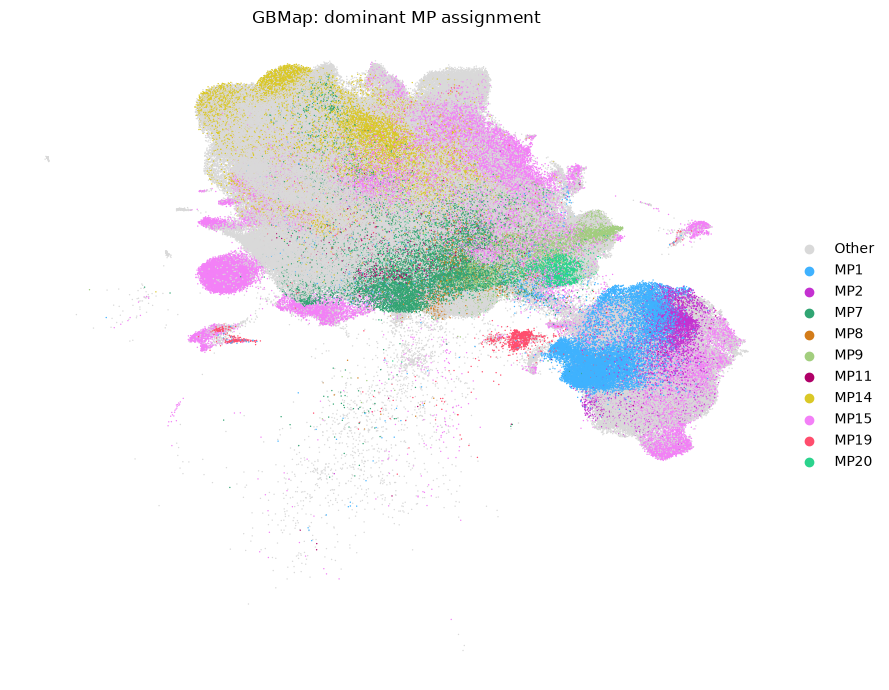

[2026-10-01 11:00:10] Saved UMAP to /net/bq-storage/ag-cherrmann/bq_cinac/projects/synimmune/results/05_significant_MP/05_all_immune_cells/05_04_umap_gbm_selected_mps_assigned.pdf


In [18]:
fig, ax = plt.subplots(figsize=(9, 7))
sc.pl.umap(
    adata,
    color="dominant_MP",
    ax=ax,
    show=False,
    size=4,
    title="GBMap: dominant MP assignment",
    palette=PALETTE,
    frameon=False,
)
fig.tight_layout()
 
out_pdf = os.path.join(OUT_DIR, "05_04_umap_gbm_selected_mps_assigned.pdf")
fig.savefig(out_pdf, bbox_inches="tight")
plt.show(fig)
plt.close(fig)
checkpoint(f"Saved UMAP to {out_pdf}")